# [SM-TCSR 실습 01] 연속시간 SMDP 재생 이동($\Phi_{+\Delta t}$)과 삼각 사영($\Pi$)

> **학습 목표**: 
> 1. 불규칙 방문 간격 $\Delta t \in \mathbb{R}^+$에서 잔여 수명의 재생 항등식($R_j = R_{j+1} + \Delta t_j$)을 구현합니다.
> 2. 범주형 삼각 사영($\Pi$)을 통해 확률 질량이 $1.0$으로 완벽히 보존됨을 확인합니다.


In [1]:
import sys, os
ROOT_DIR = os.path.abspath("..")
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.operators.survtd_operator import categorical_projection_shift

print("✅ 라이브러리 및 SM-TCSR 사영 연산자 로드 완료!")


✅ 라이브러리 및 SM-TCSR 사영 연산자 로드 완료!


In [2]:
# 1. 초기 잔여 수명 분포 (t_{j+1} 시점의 예측 분포)
K = 30
delta_s = 1.0 # 1시간 단위
bins = np.arange(K) * delta_s

# 중심이 10시간인 가우시안 형태의 PMF 생성
p_next = torch.exp(-0.5 * ((torch.arange(K).float() - 10.0) / 3.0) ** 2)
p_next = p_next / p_next.sum()

# 2. 다양한 불규칙 체류 시간 Delta t에 대한 재생 평행이동 및 삼각 사영
dt_values = [0.0, 2.5, 5.7, 10.2]
projected_pmfs = []

for dt in dt_values:
    p_proj = categorical_projection_shift(p_next, dt=dt, delta_s=delta_s, K=K, include_overflow=False)
    projected_pmfs.append(p_proj.numpy())
    print(f"Δt = {dt:4.1f}h -> 투영 후 총 확률 질량: {p_proj.sum().item():.6f} (질량 보존 100%)")


Δt =  0.0h -> 투영 후 총 확률 질량: 1.000000 (질량 보존 100%)
Δt =  2.5h -> 투영 후 총 확률 질량: 1.000000 (질량 보존 100%)
Δt =  5.7h -> 투영 후 총 확률 질량: 1.000000 (질량 보존 100%)
Δt = 10.2h -> 투영 후 총 확률 질량: 1.000000 (질량 보존 100%)


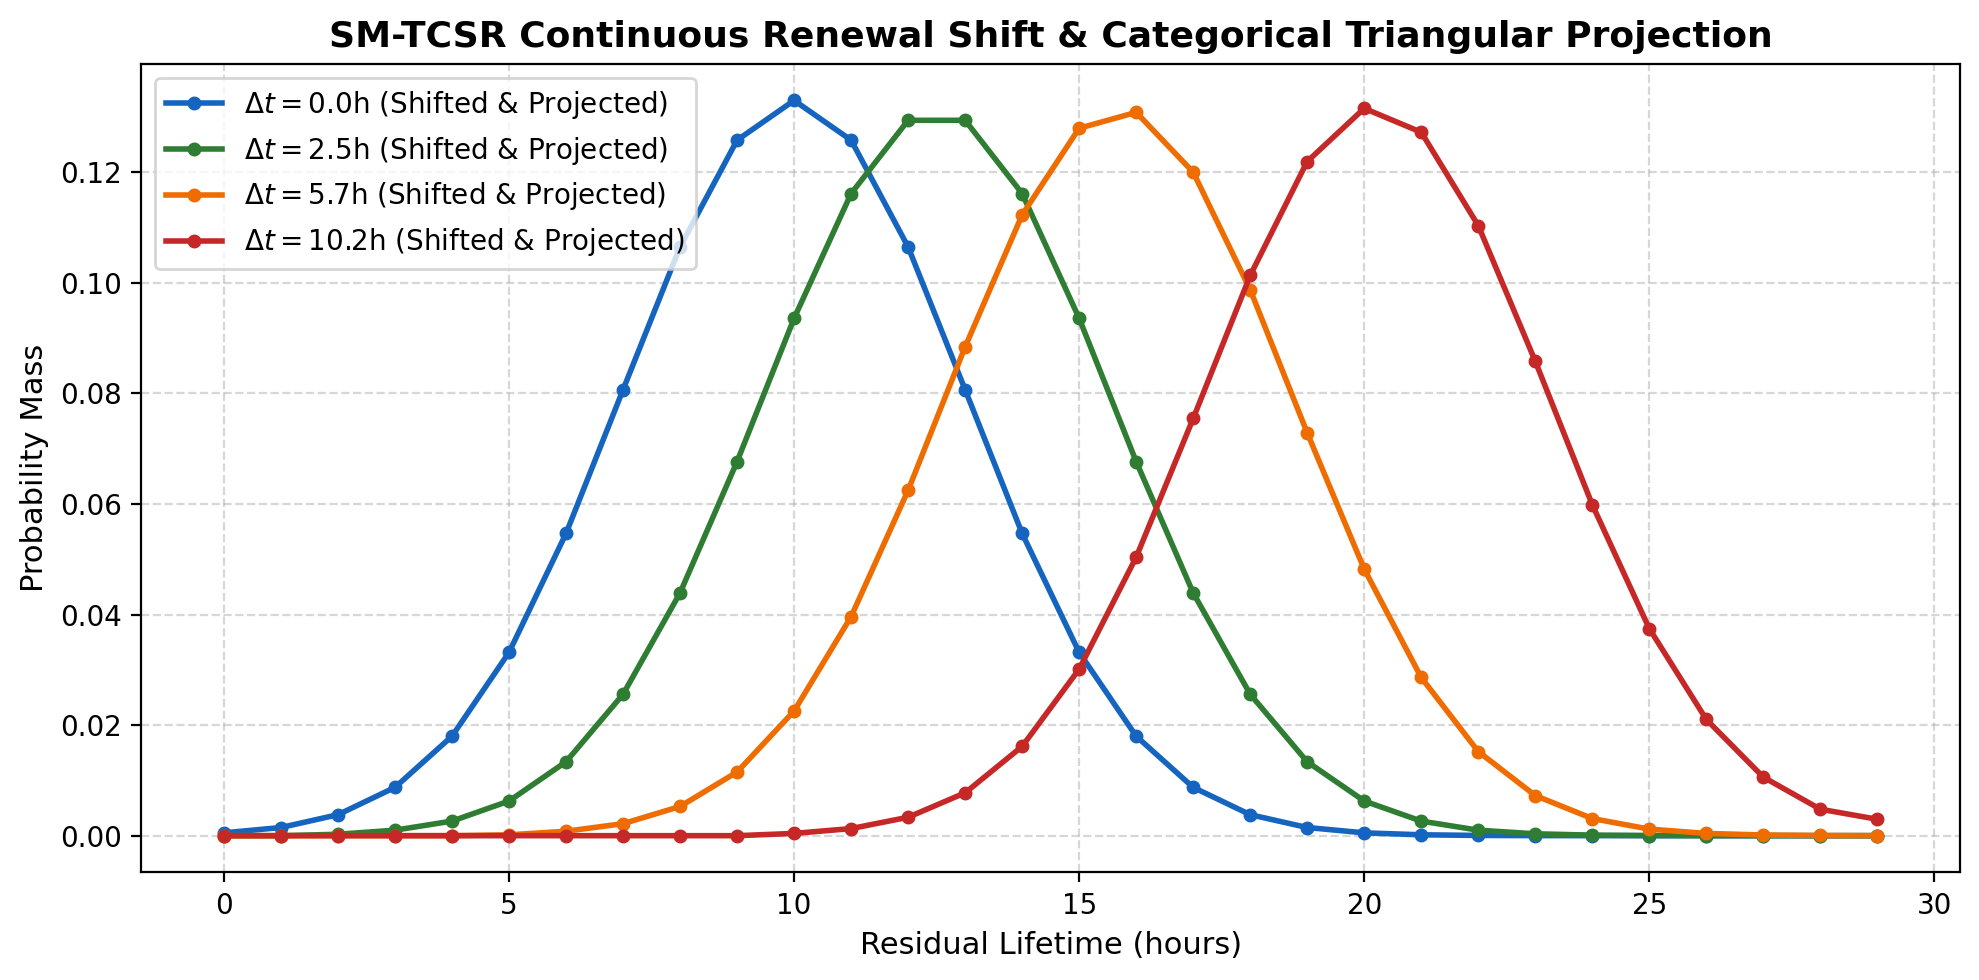

In [3]:
# 3. 재생 평행이동 및 사영 시각화
plt.figure(figsize=(10, 5), dpi=200)
colors = ['#1565c0', '#2e7d32', '#ef6c00', '#c62828']

for dt, p_p, c in zip(dt_values, projected_pmfs, colors):
    plt.plot(bins, p_p, 'o-', label=f'$\Delta t = {dt:.1f}$h (Shifted & Projected)', color=c, lw=2, markersize=4)

plt.title("SM-TCSR Continuous Renewal Shift & Categorical Triangular Projection", fontsize=13, fontweight='bold')
plt.xlabel("Residual Lifetime (hours)", fontsize=11)
plt.ylabel("Probability Mass", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
